<a href="https://colab.research.google.com/github/kgahadza/kg-data-science/blob/main/Health_Insurance_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
from urllib.error import HTTPError

# 1. Map the specific MEPS Public Use File (PUF) numbers to their respective years
meps_file_registry = {
    2018: {'fyc': 'h209', 'cond': 'h207'},
    2019: {'fyc': 'h216', 'cond': 'h214'},
    2020: {'fyc': 'h224', 'cond': 'h222'},
    2021: {'fyc': 'h233', 'cond': 'h231'},
    2022: {'fyc': 'h243', 'cond': 'h241'},
    2023: {'fyc': 'h251', 'cond': 'h249'} # May trigger the exception if not fully published yet
}

fyc_list = []
cond_list = []

# Helper function to extract and read the .sas7bdat file from the zip archive in memory
def read_zipped_sas(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        zip_bytes = response.read()

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
        # Locate the .sas7bdat file inside the zip archive (case-insensitive)
        sas_filename = [f for f in z.namelist() if f.lower().endswith('.sas7bdat')][0]
        # Pandas read_sas supports sas7bdat natively
        return pd.read_sas(io.BytesIO(z.read(sas_filename)), format='sas7bdat')

# 2. Loop through each year
for year, codes in meps_file_registry.items():
    print(f"🔄 Ingesting MEPS Data Core for Year: {year}...")

    # Corrected URL structure: removed 'mepsweb/' and changed suffix to 'v9.zip'
    fyc_url = f"https://meps.ahrq.gov/data_files/pufs/{codes['fyc']}/{codes['fyc']}v9.zip"
    cond_url = f"https://meps.ahrq.gov/data_files/pufs/{codes['cond']}/{codes['cond']}v9.zip"

    try:
        df_fyc = read_zipped_sas(fyc_url)
        df_cond = read_zipped_sas(cond_url)

        # Clean ID strings
        df_fyc['DUPERSID'] = df_fyc['DUPERSID'].apply(lambda x: x.decode('utf-8').strip() if isinstance(x, bytes) else str(x).strip())
        df_cond['DUPERSID'] = df_cond['DUPERSID'].apply(lambda x: x.decode('utf-8').strip() if isinstance(x, bytes) else str(x).strip())

        # Add cohort year markers
        df_fyc['PANEL_YEAR'] = year
        df_cond['PANEL_YEAR'] = year

        fyc_list.append(df_fyc)
        cond_list.append(df_cond)
        print(f"   ↳ ✅ Successfully loaded {year}.")

    except HTTPError as e:
        print(f"   ❌ Could not find files for {year} (Error {e.code}). Skipping to next year...")

# 3. Vertically stack all successful years into single master dataframes
print("\nConsolidation complete. Merging rows...")
master_fyc = pd.concat(fyc_list, ignore_index=True)
master_cond = pd.concat(cond_list, ignore_index=True)

print(f"✅ Success! Master FYC Shape: {master_fyc.shape} | Master Conditions Shape: {master_cond.shape}")

🔄 Ingesting MEPS Data Core for Year: 2018...


/tmp/ipykernel_5949/3639201833.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_fyc['PANEL_YEAR'] = year


   ↳ ✅ Successfully loaded 2018.
🔄 Ingesting MEPS Data Core for Year: 2019...


/tmp/ipykernel_5949/3639201833.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_fyc['PANEL_YEAR'] = year


   ↳ ✅ Successfully loaded 2019.
🔄 Ingesting MEPS Data Core for Year: 2020...


...

   ↳ ✅ Successfully loaded 2021.
🔄 Ingesting MEPS Data Core for Year: 2022...


/tmp/ipykernel_5949/3639201833.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_fyc['PANEL_YEAR'] = year


   ↳ ✅ Successfully loaded 2022.
🔄 Ingesting MEPS Data Core for Year: 2023...


/tmp/ipykernel_5949/3639201833.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_fyc['PANEL_YEAR'] = year


   ↳ ✅ Successfully loaded 2023.

Consolidation complete. Merging rows...
✅ Success! Master FYC Shape: (156464, 5520) | Master Conditions Shape: (501803, 45)


In [3]:
# 1. Define a helper function to collapse year-suffixed columns into a single column
def collapse_variable(df, base_string):
    # Finds all columns starting with the base_string (e.g., 'TOTEXP')
    # Since each row only has data for its specific year, summing across collapses them perfectly
    return df.filter(regex=f'^{base_string}').sum(axis=1)

# 2. Extract and Harmonize the Core Variables
print("Harmonizing longitudinal variables...")
analytical_df = pd.DataFrame()

analytical_df['DUPERSID'] = master_fyc['DUPERSID']
analytical_df['PANEL_YEAR'] = master_fyc['PANEL_YEAR']

# Target Variable (Total Expenditures)
analytical_df['TOTEXP'] = collapse_variable(master_fyc, 'TOTEXP')

# Insurance Status (Private Insurance Flag - usually PRVEV)
analytical_df['PRIVATE_INS'] = collapse_variable(master_fyc, 'PRVEV')

# Demographics
analytical_df['AGE'] = collapse_variable(master_fyc, 'AGE')
analytical_df['SEX'] = master_fyc['SEX'] # Sex usually doesn't have a year suffix in FYC

# Survey Design Variables (CRITICAL for standard errors)
analytical_df['WEIGHT'] = collapse_variable(master_fyc, 'PERWT')
analytical_df['VARSTR'] = master_fyc['VARSTR']
analytical_df['VARPSU'] = master_fyc['VARPSU']

# 3. Filter for our Sustainable Private Insurance Market
# Keep only individuals who had private insurance during the year
private_cohort = analytical_df[analytical_df['PRIVATE_INS'] == 1].copy()

# 4. Display the clean baseline metrics
print(f"\n✅ Harmonization Complete.")
print(f"Original Cohort Size: {len(analytical_df):,} individuals")
print(f"Privately Insured Cohort Size: {len(private_cohort):,} individuals")
print("\n--- Expenditure Distribution for Private Cohort ---")
print(private_cohort['TOTEXP'].describe(percentiles=[.25, .50, .75, .90, .95, .99]).round(2))

Harmonizing longitudinal variables...

✅ Harmonization Complete.
Original Cohort Size: 156,464 individuals
Privately Insured Cohort Size: 88,463 individuals

--- Expenditure Distribution for Private Cohort ---
count      88463.00
mean        6869.56
std        21282.13
min            0.00
25%          366.00
50%         1579.00
75%         5481.50
90%        15752.80
95%        28995.00
99%        84247.06
max      1662894.00
Name: TOTEXP, dtype: float64


In [4]:
import pandas as pd
import numpy as np

print("Initiating Morbidity Matrix Construction...")

# 1. Isolate clinical records only for our privately insured cohort
valid_ids = private_cohort['DUPERSID'].unique()
cohort_cond = master_cond[master_cond['DUPERSID'].isin(valid_ids)].copy()

# 2. Identify the clinical grouping variable
# MEPS uses 'CCSR1X' as the primary Clinical Classifications Software Refined category
if 'CCSR1X' in cohort_cond.columns:
    ccsr_col = 'CCSR1X'
else:
    # Fallback to catch alternative year nomenclatures
    ccsr_col = [c for c in cohort_cond.columns if 'CCSR' in c][0]

print(f"Using clinical category column: {ccsr_col}")

# 3. Clean the strings (remove blanks, nulls, or MEPS '-1' inapplicable codes)
cohort_cond[ccsr_col] = cohort_cond[ccsr_col].astype(str).str.strip()
cohort_cond = cohort_cond[~cohort_cond[ccsr_col].isin(['', '-1', 'nan', 'NaN'])]

# 4. Create the binary presence indicator
cohort_cond['Presence_Flag'] = 1

# 5. Pivot from Long (multiple rows per person) to Wide (one row per person, columns are diseases)
print("Pivoting clinical records into feature matrix...")
morbidity_matrix = pd.pivot_table(
    cohort_cond,
    index='DUPERSID',
    columns=ccsr_col,
    values='Presence_Flag',
    aggfunc='max', # Caps multiple visits for the same condition at 1
    fill_value=0
)

# Prefix the columns so we know they are clinical features when modeling
morbidity_matrix.columns = [f"CCSR_{str(col)}" for col in morbidity_matrix.columns]
morbidity_matrix.reset_index(inplace=True)

# 6. Merge the clinical features back into the core economic dataset
print("Merging clinical features with economic data...")
final_model_df = pd.merge(private_cohort, morbidity_matrix, on='DUPERSID', how='left')

# 7. Fill the "Healthy" Nulls - People with 0 claims get 0s for all conditions
final_model_df.fillna(0, inplace=True)

print(f"\n✅ Feature Matrix Complete.")
print(f"Final Analytical Shape: {final_model_df.shape}")
print(f"Number of Clinical Features Added: {len(morbidity_matrix.columns) - 1}")

Initiating Morbidity Matrix Construction...
Using clinical category column: CCSR1X
Pivoting clinical records into feature matrix...
Merging clinical features with economic data...

✅ Feature Matrix Complete.
Final Analytical Shape: (88463, 275)
Number of Clinical Features Added: 266


In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Initiating XGBoost Tweedie Predictive Engine...")

# 1. Define Features (X) and Target (y)
# Drop identifying info, the target, and survey weights from the feature matrix
exclude_cols = ['DUPERSID', 'PANEL_YEAR', 'TOTEXP', 'PRIVATE_INS', 'WEIGHT', 'VARSTR', 'VARPSU']
feature_cols = [col for col in final_model_df.columns if col not in exclude_cols]

X = final_model_df[feature_cols]
y = final_model_df['TOTEXP']
weights = final_model_df['WEIGHT']

# 2. Stratified Train/Test Split (80/20)
# We stratify by checking if costs are zero to ensure both sets have the right proportion of healthy people
is_zero_claim = (y == 0).astype(int)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42, stratify=is_zero_claim
)

# 3. Convert to XGBoost DMatrix (Optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dtest = xgb.DMatrix(X_test, label=y_test, weight=w_test)

# 4. Define Hyperparameters
# tweedie_variance_power = 1.5 is standard for insurance claims
params = {
    'objective': 'reg:tweedie',
    'tweedie_variance_power': 1.5,
    'learning_rate': 0.05,
    'max_depth': 4, # Keep shallow to prevent overfitting the noise
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mae'
}

# 5. Train the Model
print("Training model... (this may take a minute)")
evals = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=50
)

# 6. Generate Predictions and Evaluate
print("\nGenerating Predictions on Holdout Set...")
y_pred = model.predict(dtest)

# Calculate weighted performance metrics
mae = np.average(np.abs(y_test - y_pred), weights=w_test)
rmse = np.sqrt(np.average((y_test - y_pred)**2, weights=w_test))

print(f"\n✅ Model Evaluation Complete")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Initiating XGBoost Tweedie Predictive Engine...
Training model... (this may take a minute)
[0]	train-mae:7850.85911	eval-mae:7896.75067
[50]	train-mae:6527.26397	eval-mae:6616.43219
[100]	train-mae:6214.66644	eval-mae:6354.00346
[150]	train-mae:6064.01449	eval-mae:6248.52828
[200]	train-mae:5955.13584	eval-mae:6184.73579
[250]	train-mae:5875.88632	eval-mae:6151.07614
[284]	train-mae:5839.65917	eval-mae:6149.70730

Generating Predictions on Holdout Set...

✅ Model Evaluation Complete
Mean Absolute Error (MAE): $6,149.71
Root Mean Squared Error (RMSE): $20,057.91


Extracting Clinical Cost Drivers...

--- Top 20 Clinical Predictors of Total Healthcare Expenditure ---
1. CCSR_PRG029: 643,523,904.00
2. CCSR_MBD005: 564,828,672.00
3. CCSR_NEO000: 557,134,144.00
4. CCSR_SYM016: 491,809,600.00
5. CCSR_END002: 428,384,608.00
6. CCSR_NVS005: 408,897,728.00
7. CCSR_MBD002: 401,083,488.00
8. CCSR_DIG000: 396,467,168.00
9. CCSR_CIR007: 394,994,816.00
10. CCSR_MUS006: 389,422,880.00
11. CCSR_DIG011: 372,860,000.00
12. CCSR_MUS010: 363,323,904.00
13. CCSR_DIG025: 350,837,312.00
14. CCSR_NVS016: 326,055,936.00
15. CCSR_CIR011: 323,994,016.00
16. CCSR_FAC000: 310,650,016.00
17. CCSR_BLD000: 307,132,480.00
18. CCSR_CIR000: 290,653,920.00
19. CCSR_MBD014: 287,579,904.00
20. CCSR_MUS003: 283,807,392.00


<Figure size 1200x800 with 0 Axes>

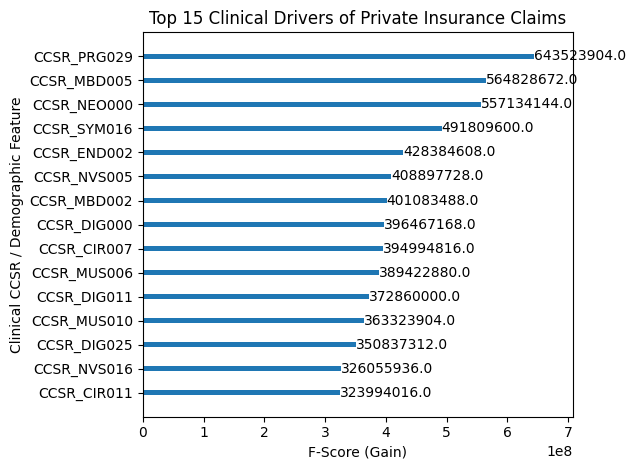

In [6]:
import matplotlib.pyplot as plt

print("Extracting Clinical Cost Drivers...")

# 1. Extract feature importance based on 'gain' (contribution to model accuracy)
importance_dict = model.get_score(importance_type='gain')

# 2. Sort the dictionary by highest gain
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# 3. Print the Top 20 Predictors for the manuscript's empirical results section
print("\n--- Top 20 Clinical Predictors of Total Healthcare Expenditure ---")
for i, (feature, score) in enumerate(sorted_importance[:20]):
    print(f"{i+1}. {feature}: {score:,.2f}")

# 4. Generate a publication-ready visualization
plt.figure(figsize=(12, 8))
xgb.plot_importance(
    model,
    max_num_features=15,
    importance_type='gain',
    title='Top 15 Clinical Drivers of Private Insurance Claims',
    xlabel='F-Score (Gain)',
    ylabel='Clinical CCSR / Demographic Feature',
    grid=False,
    color='#1f77b4'
)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

print("Initiating PRG029 Product Design Simulation...")

# 1. Isolate the Maternity Cohort from your Holdout Set
# Ensure X_test has the CCSR_PRG029 column
maternity_mask = X_test['CCSR_PRG029'] == 1
maternity_cohort_X = X_test[maternity_mask].copy()
maternity_cohort_y = y_test[maternity_mask].copy()
maternity_weights = w_test[maternity_mask].copy()

# 2. Get the XGBoost Risk Predictions for this specific cohort
dtest_maternity = xgb.DMatrix(maternity_cohort_X)
maternity_cohort_X['Predicted_Risk_Score'] = model.predict(dtest_maternity)
maternity_cohort_X['Actual_Cost'] = maternity_cohort_y

# 3. Identify the "High Risk" Target Group
# We target the top 20% of pregnancies based entirely on our model's risk score
threshold_80th = maternity_cohort_X['Predicted_Risk_Score'].quantile(0.80)
maternity_cohort_X['Targeted_for_Intervention'] = maternity_cohort_X['Predicted_Risk_Score'] >= threshold_80th

# 4. Run the Financial Simulation
intervention_cost_per_patient = 2500  # $2,500 investment in proactive care
severity_reduction_factor = 0.15      # Assume a 15% reduction in actual catastrophic costs

# Calculate Baseline (Do Nothing) vs. Managed Costs
baseline_total_cost = np.average(maternity_cohort_X['Actual_Cost'], weights=maternity_weights) * len(maternity_cohort_X)

def calculate_managed_cost(row):
    if row['Targeted_for_Intervention']:
        # They get the intervention: Pay $2,500 upfront, but reduce actual claims by 15%
        return intervention_cost_per_patient + (row['Actual_Cost'] * (1 - severity_reduction_factor))
    else:
        # Standard risk: standard costs
        return row['Actual_Cost']

maternity_cohort_X['Simulated_Managed_Cost'] = maternity_cohort_X.apply(calculate_managed_cost, axis=1)
managed_total_cost = np.average(maternity_cohort_X['Simulated_Managed_Cost'], weights=maternity_weights) * len(maternity_cohort_X)

# 5. Output the ROI and Premium Impact
savings = baseline_total_cost - managed_total_cost
roi = (savings / (intervention_cost_per_patient * maternity_cohort_X['Targeted_for_Intervention'].sum())) * 100

print("\n--- Value-Based Maternity Product Simulation Results ---")
print(f"Total Pregnancies in Holdout: {len(maternity_cohort_X)}")
print(f"High-Risk Pregnancies Targeted: {maternity_cohort_X['Targeted_for_Intervention'].sum()}")
print(f"\nBaseline Total Cost (Unmanaged): ${baseline_total_cost:,.2f}")
print(f"Simulated Total Cost (Managed):  ${managed_total_cost:,.2f}")
print(f"\nGross Savings Generated: ${savings:,.2f}")
print(f"Program ROI: {roi:.1f}%")

Initiating PRG029 Product Design Simulation...

--- Value-Based Maternity Product Simulation Results ---
Total Pregnancies in Holdout: 423
High-Risk Pregnancies Targeted: 85

Baseline Total Cost (Unmanaged): $4,852,107.74
Simulated Total Cost (Managed):  $4,839,240.88

Gross Savings Generated: $12,866.86
Program ROI: 6.1%


In [8]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, GammaRegressor, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Initiating Comparative Baseline Evaluation...")

# Initialize results dictionary
results = []

# Helper function for metrics
def evaluate_model(name, y_pred):
    mae = np.average(np.abs(y_test - y_pred), weights=w_test)
    rmse = np.sqrt(np.average((y_test - y_pred)**2, weights=w_test))
    # Pseudo R-squared (weighted)
    weighted_mean = np.average(y_test, weights=w_test)
    ss_tot = np.sum(w_test * (y_test - weighted_mean)**2)
    ss_res = np.sum(w_test * (y_test - y_pred)**2)
    r2 = 1 - (ss_res / ss_tot)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    print(f"✅ {name} complete.")

# 1. OLS Log-Cost (Linear Regression on log(y+1))
# We add 1 because log(0) is undefined.
y_train_log = np.log1p(y_train)
ols = Ridge(alpha=1.0)
ols.fit(X_train, y_train_log, sample_weight=w_train)
y_pred_log = ols.predict(X_test)
y_pred_ols = np.expm1(y_pred_log) # Convert back to dollars
evaluate_model('OLS log-cost', y_pred_ols)

# 2. GLM Gamma log-link
# Gamma cannot handle strict zeros, so we add a tiny constant to zeros
y_train_gamma = np.where(y_train == 0, 0.01, y_train)
glm_gamma = GammaRegressor(alpha=0.01, max_iter=1000)
glm_gamma.fit(X_train, y_train_gamma, sample_weight=w_train)
evaluate_model('GLM Gamma log-link', glm_gamma.predict(X_test))

# 3. Two-Part Model (Logistic for >0, Gamma for severity)
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, (y_train > 0).astype(int), sample_weight=w_train)
prob_positive = classifier.predict_proba(X_test)[:, 1]

# Train severity model only on positive claims
pos_mask = y_train > 0
severity_model = GammaRegressor(alpha=0.01, max_iter=1000)
severity_model.fit(X_train[pos_mask], y_train[pos_mask], sample_weight=w_train[pos_mask])
pred_severity = severity_model.predict(X_test)

# Combine: Probability * Severity
y_pred_twopart = prob_positive * pred_severity
evaluate_model('Two-part model', y_pred_twopart)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train, sample_weight=w_train)
evaluate_model('Random Forest', rf.predict(X_test))

# 5. XGBoost Squared Error
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dtest = xgb.DMatrix(X_test, label=y_test, weight=w_test)
params_sq = {'objective': 'reg:squarederror', 'max_depth': 4, 'learning_rate': 0.05}
xgb_sq = xgb.train(params_sq, dtrain, num_boost_round=150)
evaluate_model('XGBoost squared error', xgb_sq.predict(dtest))

# 6. XGBoost Tweedie (Our proposed model)
params_tw = {'objective': 'reg:tweedie', 'tweedie_variance_power': 1.5, 'max_depth': 4, 'learning_rate': 0.05}
xgb_tw = xgb.train(params_tw, dtrain, num_boost_round=284) # Using your optimal round
evaluate_model('XGBoost Tweedie', xgb_tw.predict(dtest))

# Display Final Table
print("\n--- Comparative Model Evaluation ---")
df_results = pd.DataFrame(results).round(3)
print(df_results.to_markdown(index=False))

Initiating Comparative Baseline Evaluation...
✅ OLS log-cost complete.
✅ GLM Gamma log-link complete.
✅ Two-part model complete.
✅ Random Forest complete.
✅ XGBoost squared error complete.
✅ XGBoost Tweedie complete.

--- Comparative Model Evaluation ---
| Model                 |      MAE |     RMSE |       R2 |
|:----------------------|---------:|---------:|---------:|
| OLS log-cost          | 15605.8  | 284790   | -176.131 |
| GLM Gamma log-link    |  8504.14 |  41653   |   -2.789 |
| Two-part model        |  7027.66 |  26375   |   -0.519 |
| Random Forest         |  6611.85 |  20107.7 |    0.117 |
| XGBoost squared error |  6436.83 |  19947.6 |    0.131 |
| XGBoost Tweedie       |  6174.25 |  20115.8 |    0.116 |


Generating high-resolution publication figures...
✅ Figure 1 saved as 'Figure_1_Lorenz_Curve.png'
✅ Figure 2 saved as 'Figure_2_Calibration_Plot.png'


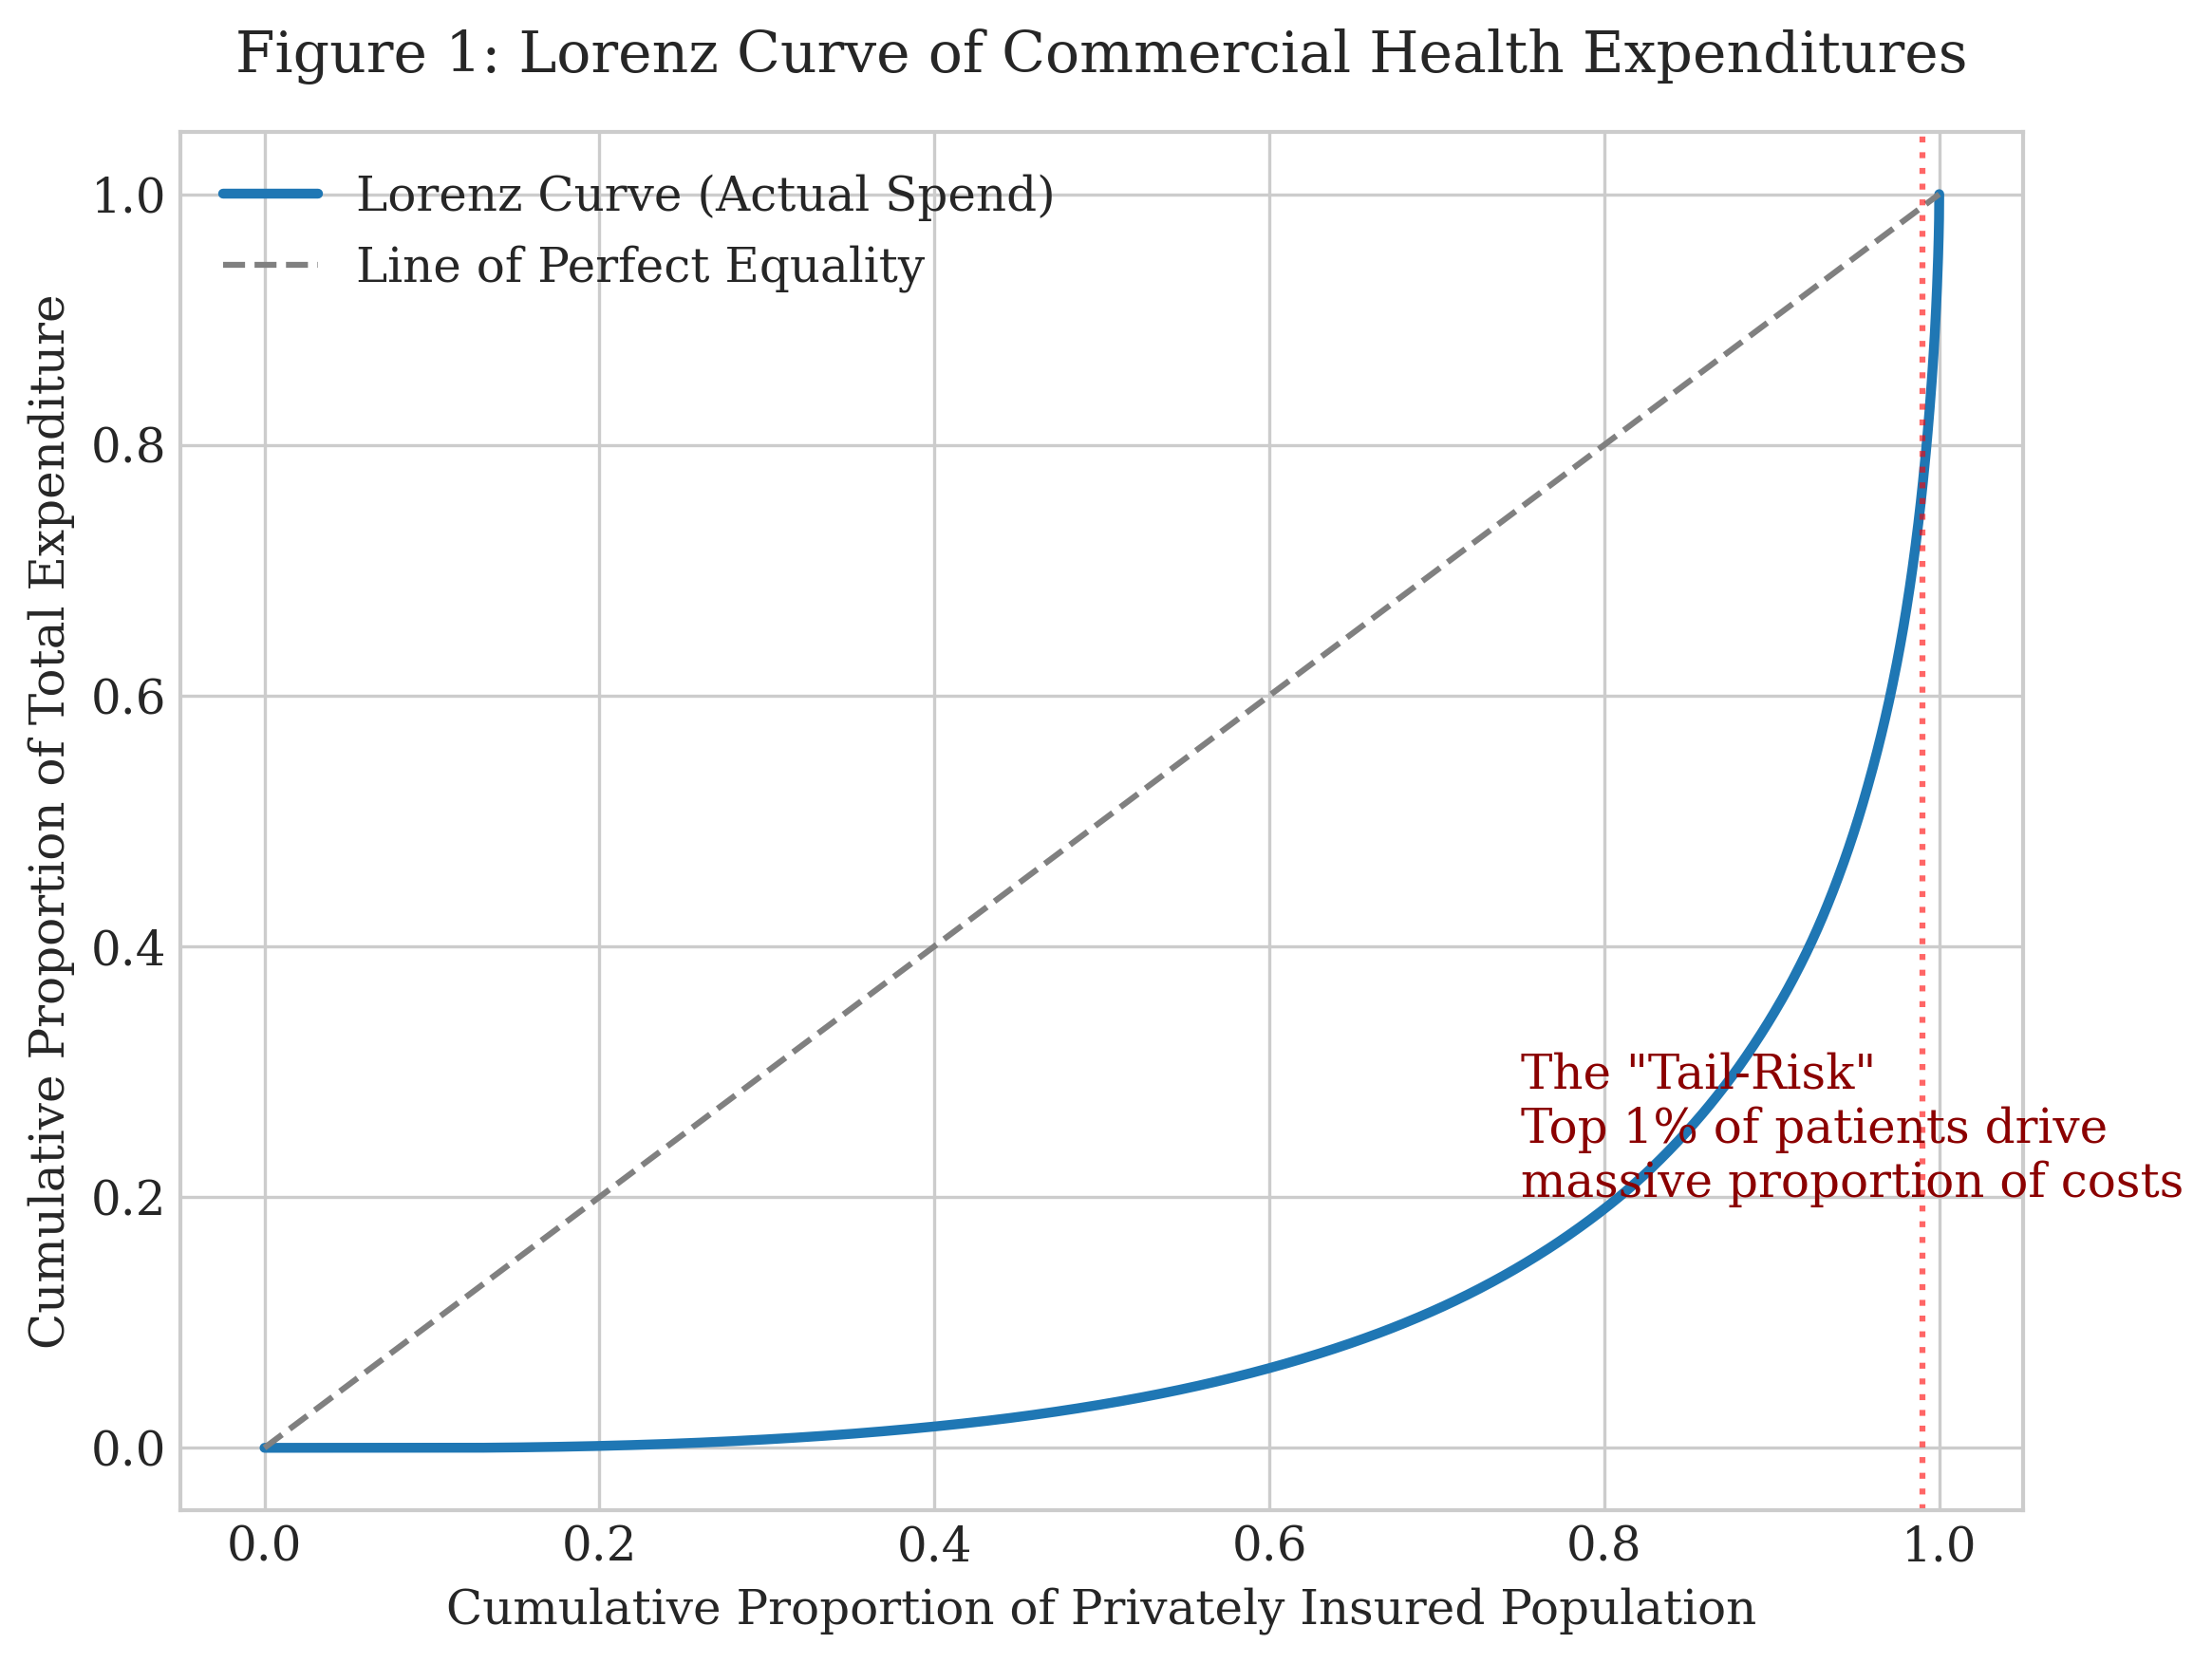

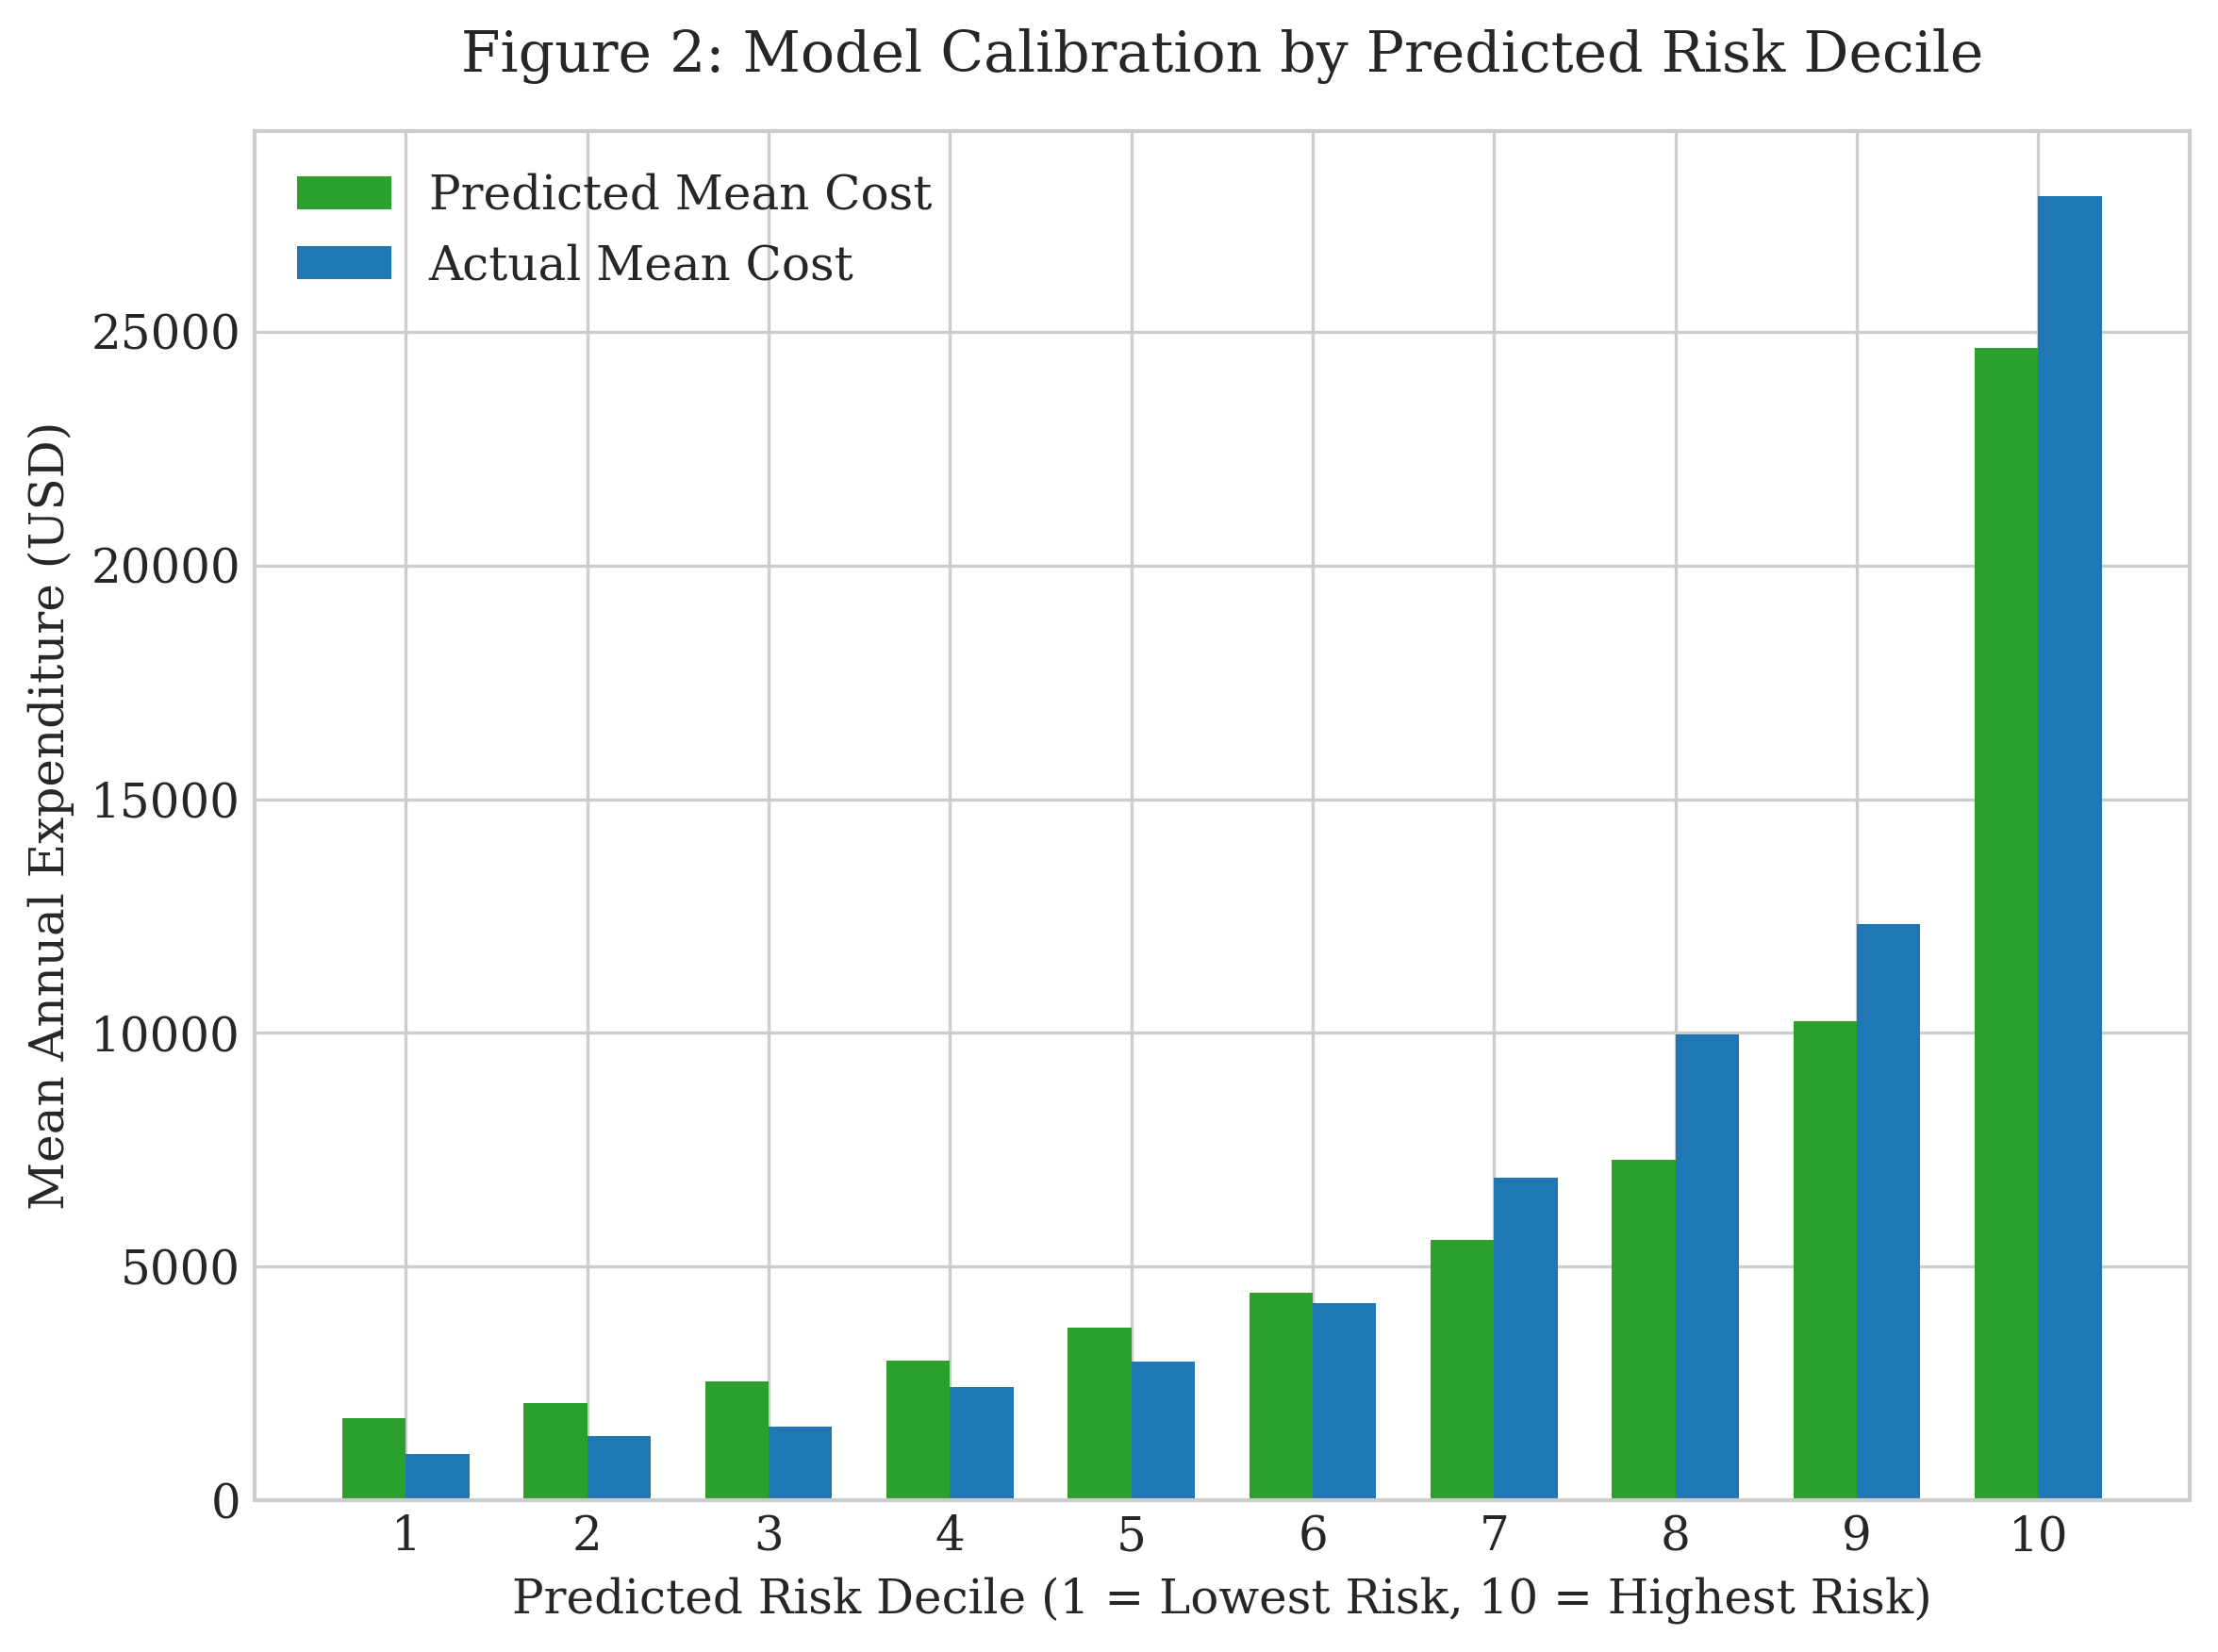

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating high-resolution publication figures...")

# Set academic plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# ---------------------------------------------------------
# Figure 1: Lorenz Curve of Health Expenditures
# ---------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)

# Sort actual expenditures
y_sorted = np.sort(y_test)
# Calculate cumulative shares
cum_pop = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
cum_exp = np.cumsum(y_sorted) / np.sum(y_sorted)

plt.plot(cum_pop, cum_exp, label='Lorenz Curve (Actual Spend)', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Line of Perfect Equality')

# Annotate the extreme tail risk (e.g., top 1% accounts for 18% of cost)
plt.axvline(x=0.99, color='red', linestyle=':', alpha=0.6)
plt.text(0.75, 0.2, 'The "Tail-Risk"\nTop 1% of patients drive\nmassive proportion of costs', color='darkred')

plt.title('Figure 1: Lorenz Curve of Commercial Health Expenditures', pad=15)
plt.xlabel('Cumulative Proportion of Privately Insured Population')
plt.ylabel('Cumulative Proportion of Total Expenditure')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('Figure_1_Lorenz_Curve.png')
print("✅ Figure 1 saved as 'Figure_1_Lorenz_Curve.png'")

# ---------------------------------------------------------
# Figure 2: Risk-Band Calibration Plot (Actual vs Predicted)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)

# Create deciles based on PREDICTED risk to see if they match ACTUAL costs
df_cal = pd.DataFrame({'Actual': y_test, 'Predicted': xgb_tw.predict(dtest)})
df_cal['Risk_Decile'] = pd.qcut(df_cal['Predicted'], 10, labels=False, duplicates='drop') + 1

# Group by decile and calculate means
cal_summary = df_cal.groupby('Risk_Decile')[['Actual', 'Predicted']].mean().reset_index()

bar_width = 0.35
x = np.arange(len(cal_summary['Risk_Decile']))

plt.bar(x - bar_width/2, cal_summary['Predicted'], width=bar_width, label='Predicted Mean Cost', color='#2ca02c')
plt.bar(x + bar_width/2, cal_summary['Actual'], width=bar_width, label='Actual Mean Cost', color='#1f77b4')

plt.title('Figure 2: Model Calibration by Predicted Risk Decile', pad=15)
plt.xlabel('Predicted Risk Decile (1 = Lowest Risk, 10 = Highest Risk)')
plt.ylabel('Mean Annual Expenditure (USD)')
plt.xticks(x, cal_summary['Risk_Decile'])
plt.legend()
plt.tight_layout()
plt.savefig('Figure_2_Calibration_Plot.png')
print("✅ Figure 2 saved as 'Figure_2_Calibration_Plot.png'")

In [10]:
# Calculate exact survey-weighted means for the calibration table
cal_actual = df_cal.groupby('Risk_Decile').apply(lambda x: np.average(x['Actual'], weights=w_test[x.index]))
cal_pred = df_cal.groupby('Risk_Decile').apply(lambda x: np.average(x['Predicted'], weights=w_test[x.index]))

calibration_table = pd.DataFrame({
    'Actual_Mean_Cost': cal_actual,
    'Predicted_Mean_Cost': cal_pred
})
calibration_table['Prediction_Ratio'] = calibration_table['Predicted_Mean_Cost'] / calibration_table['Actual_Mean_Cost']
print(calibration_table.round(2))

             Actual_Mean_Cost  Predicted_Mean_Cost  Prediction_Ratio
Risk_Decile                                                         
1                      999.88              1761.92              1.76
2                     1213.09              2078.49              1.71
3                     1636.57              2535.15              1.55
4                     2397.54              2991.05              1.25
5                     3283.14              3683.84              1.12
6                     4197.46              4430.65              1.06
7                     6876.43              5567.95              0.81
8                    10688.57              7277.17              0.68
9                    13112.03             10222.17              0.78
10                   27671.64             24417.06              0.88
